#Notebook 03: EDA General — Gráficos Resumen
**Plan de Compras 2025 — MINVU**

Este notebook realiza la carga de datos del archivo .xlsx completo sobre el plan de compras y hace la extracción de los datos, además, incluye estadísticas descriptivas y gráficos resumen generales.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings('ignore')

# ── Carga de datos ──────────────────────────────────────────
df = pd.read_excel('plan_de_compras_2025.xlsx')

# Extraer año del código de proyecto (últimos 2 dígitos tras 'PC')
df['anio_codigo'] = df['ID Proyecto'].str.extract(r'PC(\d{2})$')

# Formatear fechas
df['Fecha de Inicio Compra'] = pd.to_datetime(df['Fecha de Inicio Compra'], errors='coerce')
df['Fecha Publicación PAC 2025'] = pd.to_datetime(df['Fecha Publicación PAC 2025'], errors='coerce')

print(f"Total registros: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
print(f"\nDistribución por año de código de proyecto:")
print(df['anio_codigo'].value_counts().sort_index())
df.head(3)


Total registros: 831
Columnas: 27

Distribución por año de código de proyecto:
anio_codigo
22      5
23     81
24     97
25    648
Name: count, dtype: int64


,Unidad de Compra,ID Proyecto,Tipo Proyecto,Estado Proyecto,Código presupuestario,Nombre Proyecto,Descripción Proyecto,Cantidad de Ítems,Nombre ítem,Tipo compra,...,Teléfono responsable,Correo responsable,Fecha de Inicio Compra,Fecha Publicación PAC 2025,Cantidad OC Asociadas Ítem 2025,OC Asociada Item 2025,Item De Arraste,Monto De Arrastre,Meses envio OC de Arraste,anio_codigo
0,Ministerio de Vivienda y Urbanismo(766),587-259-PC22,Proyecto estratégico,Publicado,2207-2209-33,Servicio arriendo de una plataforma de gestión...,Servicio de arriendo de una plataforma de gest...,2,Servicio arriendo de una plataforma de gestión...,1,...,2 -2901 1198-,mzunigas@minvu.cl,2022-11-01,2022-11-08,0,NaN,1,20000000,2025-01-01,22
1,SEREMI MINVU V REGION,632-28-PC22,Proyecto operacional,Publicado,2206-2206001,Servicio de Mantención y Reparaciones Menores ...,Convenio de Suministro para el Servicio de Man...,1,Mantenimiento y Reparación de Edificaciones,1,...,32-2186802-,agardaix@minvu.cl,2022-02-01,2022-11-08,1,632-7-SE22,1,4500000,2025-01-01,22
2,SEREMI MINVU V REGION,632-32-PC22,Proyecto operacional,Publicado,2204001,Servicios de Impresión-Seremi Valparaiso,Servicios de Impresión de Materiales SEREMI y ...,1,Materiales de Oficina,1,...,32-2186802-,agardaix@minvu.cl,2022-08-01,2022-11-08,0,NaN,1,3825000,2025-01-01,22


## 1. Estadísticas Descriptivas

In [3]:
resumen = df[['Monto Total Ítem Año 2025', 'Monto Unitario Ítem',
              'Cantidad de Ítems', 'Cantidad OC', 'Cantidad Productos']].describe()

# Formatear montos en millones
for col in ['Monto Total Ítem Año 2025', 'Monto Unitario Ítem']:
    resumen[col] = resumen[col].apply(lambda x: f"${x/1e6:,.1f}M")

print("Estadísticas descriptivas principales:")
resumen


Estadísticas descriptivas principales:


,Monto Total Ítem Año 2025,Monto Unitario Ítem,Cantidad de Ítems,Cantidad OC,Cantidad Productos
count,$0.0M,$0.0M,831.000000,831.000000,831.0
mean,$101.5M,$108.5M,1.199759,1.344164,1.0
std,$202.5M,$203.6M,0.414845,1.263753,0.0
min,$0.0M,$0.1M,1.000000,1.000000,1.0
25%,$3.0M,$4.2M,1.000000,1.000000,1.0
50%,$35.0M,$40.0M,1.000000,1.000000,1.0
75%,$202.0M,$202.0M,1.000000,1.000000,1.0
max,"$4,839.0M","$4,839.0M",3.000000,12.000000,1.0


## 2. Distribución por Tipo y Estado de Proyecto

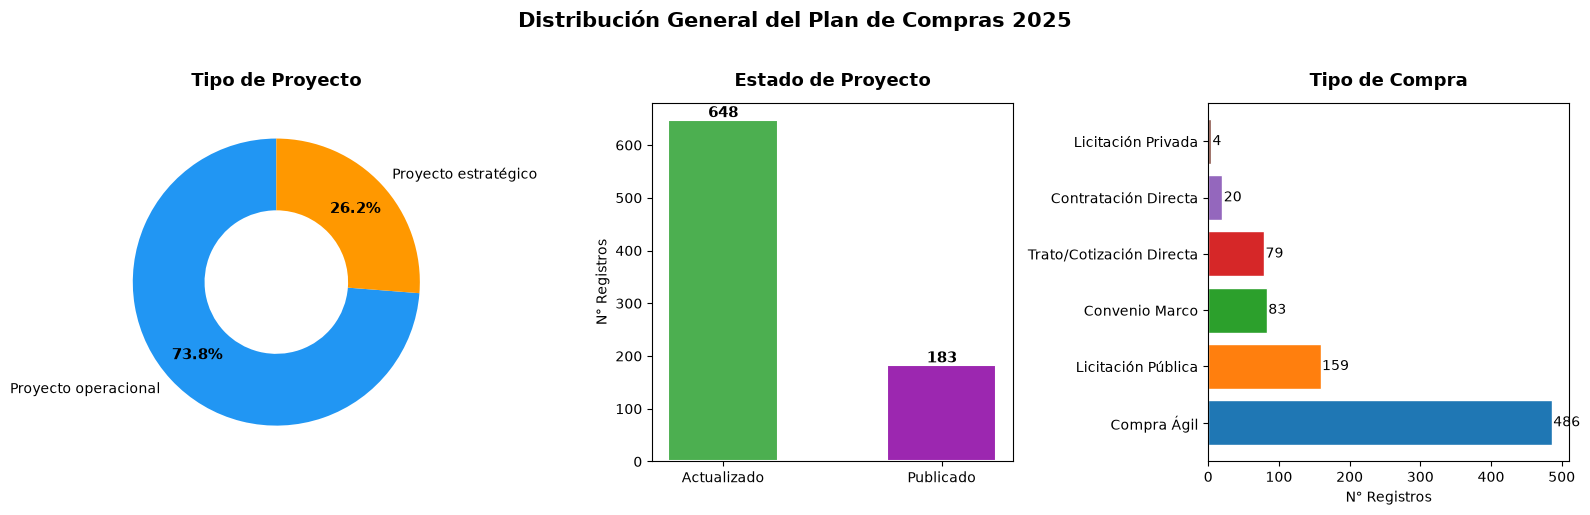

Gráfico guardado.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# -- Tipo de proyecto --
tipo_cnt = df['Tipo Proyecto'].value_counts()
colors_tipo = ['#2196F3', '#FF9800']
wedges, texts, autotexts = axes[0].pie(
    tipo_cnt.values, labels=tipo_cnt.index,
    autopct='%1.1f%%', colors=colors_tipo,
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.5)
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold')
axes[0].set_title('Tipo de Proyecto', fontsize=13, fontweight='bold', pad=12)

# -- Estado de proyecto --
estado_cnt = df['Estado Proyecto'].value_counts()
colors_est = ['#4CAF50', '#9C27B0']
axes[1].bar(estado_cnt.index, estado_cnt.values,
            color=colors_est, edgecolor='white', linewidth=1.5, width=0.5)
axes[1].set_title('Estado de Proyecto', fontsize=13, fontweight='bold', pad=12)
axes[1].set_ylabel('N° Registros')
for bar, val in zip(axes[1].patches, estado_cnt.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)

# -- Tipo de compra --
tc_map = {1: 'Licitación Pública', 2: 'Licitación Privada',
          3: 'Contratación Directa', 4: 'Convenio Marco',
          5: 'Trato/Cotización Directa', 6: 'Compra Ágil'}
df['Tipo compra desc'] = df['Tipo compra'].map(tc_map).fillna(df['Tipo compra'].astype(str))
tc_cnt = df['Tipo compra desc'].value_counts()
bars = axes[2].barh(tc_cnt.index, tc_cnt.values,
                    color=sns.color_palette("tab10", len(tc_cnt)), edgecolor='white')
axes[2].set_title('Tipo de Compra', fontsize=13, fontweight='bold', pad=12)
axes[2].set_xlabel('N° Registros')
for bar, val in zip(bars, tc_cnt.values):
    axes[2].text(val + 2, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=10)

plt.suptitle('Distribución General del Plan de Compras 2025', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_tipo_estado_compra.png', bbox_inches='tight', dpi=150)
plt.show()
print("Gráfico guardado.")


## 3. Top Unidades de Compra — Monto Total

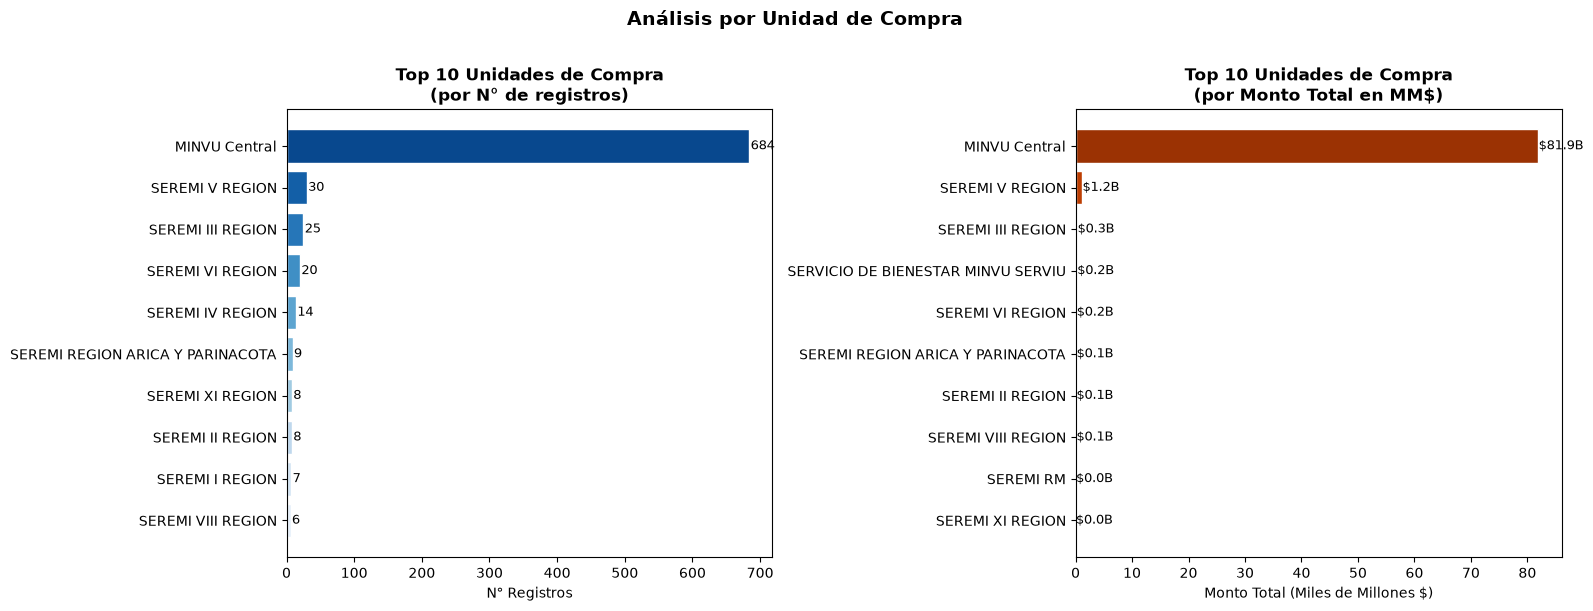

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -- Por N° registros --
uc_cnt = df['Unidad de Compra'].value_counts().head(10)
uc_short = [u.replace('Ministerio de Vivienda y Urbanismo(766)', 'MINVU Central')
             .replace('SEREMI MINVU ', 'SEREMI ') for u in uc_cnt.index]
colors = sns.color_palette("Blues_r", len(uc_cnt))
bars = axes[0].barh(uc_short[::-1], uc_cnt.values[::-1], color=colors[::-1], edgecolor='white')
axes[0].set_title('Top 10 Unidades de Compra\n(por N° de registros)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('N° Registros')
for bar, val in zip(bars, uc_cnt.values[::-1]):
    axes[0].text(val + 2, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

# -- Por Monto Total --
uc_monto = df.groupby('Unidad de Compra')['Monto Total Ítem Año 2025'].sum().nlargest(10)
uc_monto_short = [u.replace('Ministerio de Vivienda y Urbanismo(766)', 'MINVU Central')
                   .replace('SEREMI MINVU ', 'SEREMI ') for u in uc_monto.index]
colors2 = sns.color_palette("Oranges_r", len(uc_monto))
bars2 = axes[1].barh(uc_monto_short[::-1], (uc_monto.values / 1e9)[::-1], color=colors2[::-1], edgecolor='white')
axes[1].set_title('Top 10 Unidades de Compra\n(por Monto Total en MM$)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Monto Total (Miles de Millones $)')
for bar, val in zip(bars2, (uc_monto.values / 1e9)[::-1]):
    axes[1].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'${val:.1f}B', va='center', fontsize=9)

plt.suptitle('Análisis por Unidad de Compra', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_unidades_compra.png', bbox_inches='tight', dpi=150)
plt.show()


## 4. Top 10 Proyectos por Monto Total

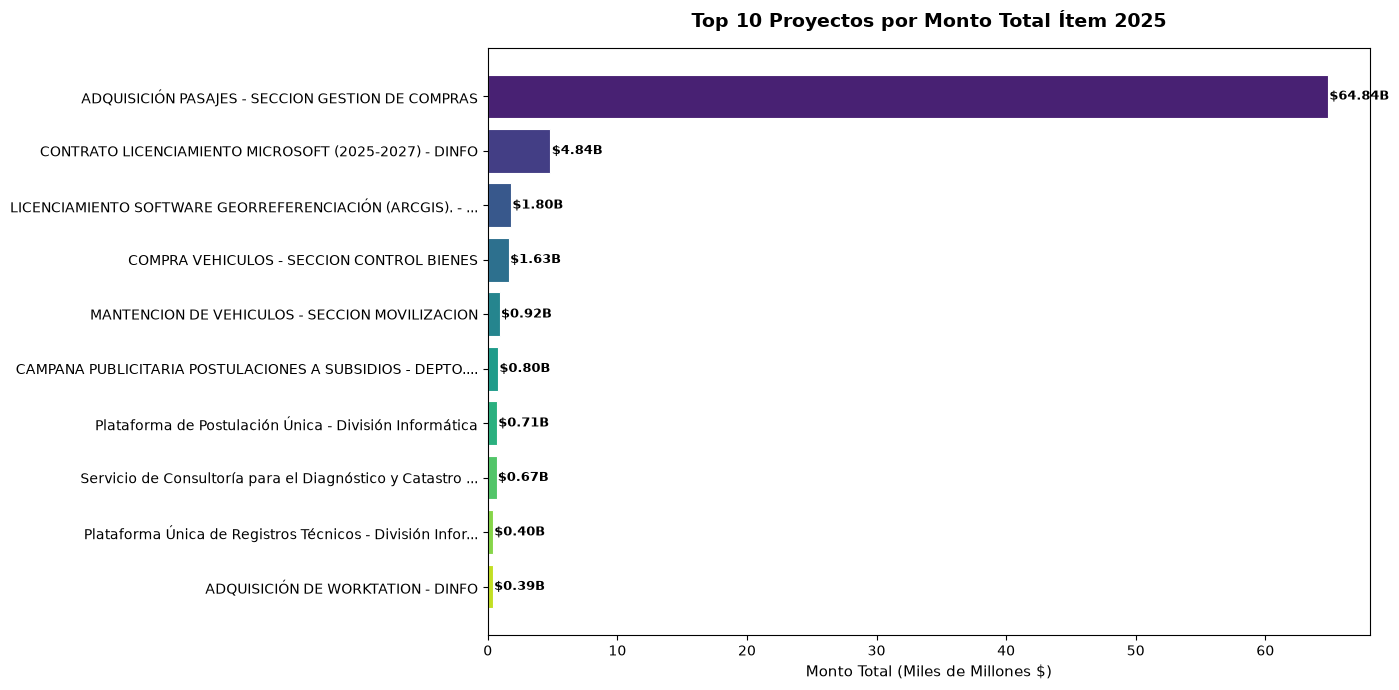

In [6]:
top_proy = (df.groupby('Nombre Proyecto')['Monto Total Ítem Año 2025']
              .sum().nlargest(10))

fig, ax = plt.subplots(figsize=(14, 7))
nombres_cortos = [n[:55] + ('...' if len(n) > 55 else '') for n in top_proy.index]
colores = sns.color_palette("viridis", len(top_proy))
bars = ax.barh(nombres_cortos[::-1], (top_proy.values / 1e9)[::-1],
               color=colores[::-1], edgecolor='white', linewidth=0.8)
ax.set_xlabel('Monto Total (Miles de Millones $)', fontsize=11)
ax.set_title('Top 10 Proyectos por Monto Total Ítem 2025', fontsize=14, fontweight='bold', pad=15)
for bar, val in zip(bars, (top_proy.values / 1e9)[::-1]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'${val:.2f}B', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_top_proyectos.png', bbox_inches='tight', dpi=150)
plt.show()


## 5. Distribución de Montos

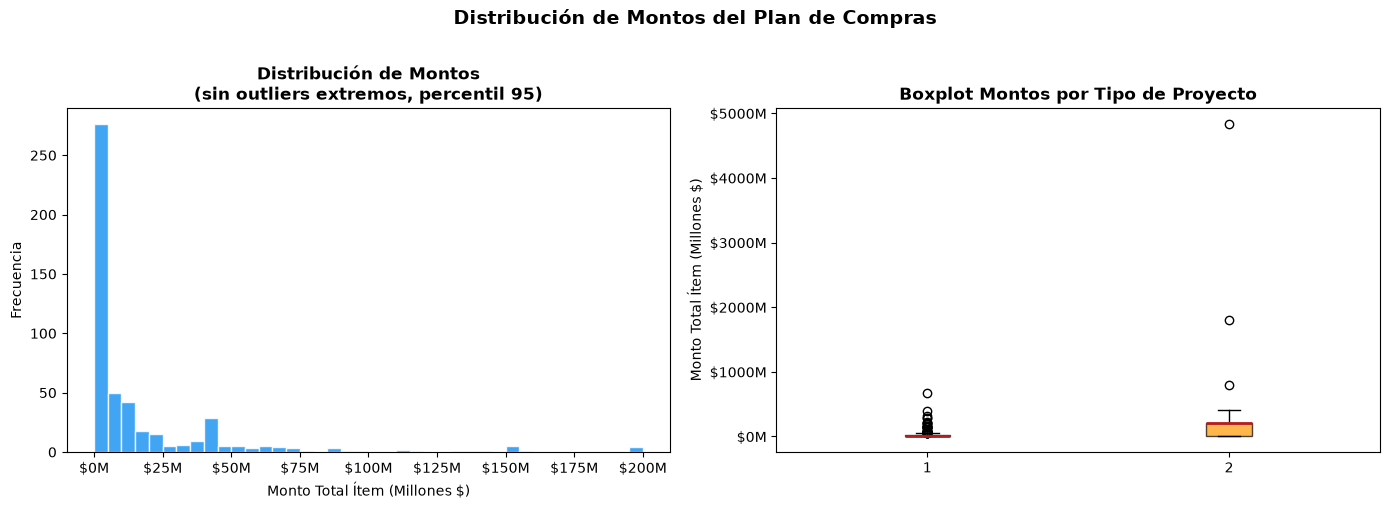

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma (sin outliers extremos para mejor visualización)
monto_filtrado = df[df['Monto Total Ítem Año 2025'] < df['Monto Total Ítem Año 2025'].quantile(0.95)]
axes[0].hist(monto_filtrado['Monto Total Ítem Año 2025'] / 1e6, bins=40,
             color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Monto Total Ítem (Millones $)', fontsize=10)
axes[0].set_ylabel('Frecuencia', fontsize=10)
axes[0].set_title('Distribución de Montos\n(sin outliers extremos, percentil 95)', fontsize=12, fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))

# Boxplot por tipo de proyecto
tipos = df['Tipo Proyecto'].unique()
data_box = [df[df['Tipo Proyecto'] == t]['Monto Total Ítem Año 2025'].dropna() / 1e6
            for t in tipos]
bp = axes[1].boxplot(data_box, label=[t.replace('Proyecto ', '') for t in tipos],
                     patch_artist=True, notch=False,
                     boxprops=dict(facecolor='#FF9800', alpha=0.7),
                     medianprops=dict(color='#B71C1C', linewidth=2))
axes[1].set_ylabel('Monto Total Ítem (Millones $)')
axes[1].set_title('Boxplot Montos por Tipo de Proyecto', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))

plt.suptitle('Distribución de Montos del Plan de Compras', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_distribucion_montos.png', bbox_inches='tight', dpi=150)
plt.show()


## 6. Correlación entre Variables Numéricas

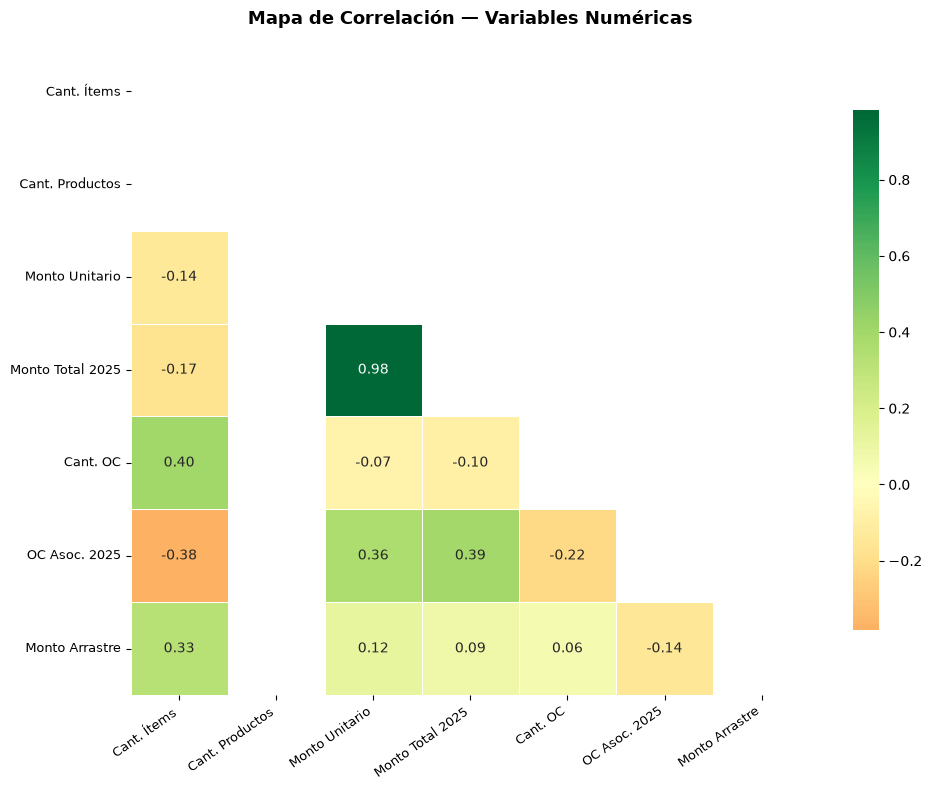

In [9]:
num_cols = ['Cantidad de Ítems', 'Cantidad Productos', 'Monto Unitario Ítem',
            'Monto Total Ítem Año 2025', 'Cantidad OC',
            'Cantidad OC Asociadas Ítem 2025', 'Monto De Arrastre']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Mapa de Correlación — Variables Numéricas', fontsize=13, fontweight='bold', pad=15)
short_labels = ['Cant. Ítems', 'Cant. Productos', 'Monto Unitario',
                'Monto Total 2025', 'Cant. OC', 'OC Asoc. 2025', 'Monto Arrastre']
ax.set_xticklabels(short_labels, rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(short_labels, rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('eda_correlacion.png', bbox_inches='tight', dpi=150)
plt.show()
